# Classification & Regression: Boosting, Bagging, and Imbalanced Data

**COMP4040**

---

### Instructions
- Complete all cells marked with `# YOUR CODE HERE`.
- Answer all written questions in the provided Markdown cells.
- Do **not** modify the helper functions or data generation code.
- Run all cells from top to bottom before submitting.


# Part 1: Boosting and Bagging

In [2]:
import sklearn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.datasets import make_moons, make_blobs
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

In [3]:
#@title Visualization helper (do not modify)
def viz(clf, X_train, y_train, candidate=False):
    h = 0.02
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    if candidate:
        Z = clf.predict(xgb.DMatrix(np.c_[xx.ravel(), yy.ravel()]))
    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(1)
    plt.clf()
    plt.imshow(Z, interpolation='nearest',
               extent=(xx.min(), xx.max(), yy.min(), yy.max()),
               cmap=plt.cm.Paired, aspect='auto', origin='lower')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
    plt.title('Decision Boundary')
    plt.show()

def results(clf):
    clf.fit(X_train, y_train)
    print('Test data')
    viz(clf, X_test, y_test)
    print('Test accuracy: ', (clf.predict(X_test) == y_test).mean())

In [4]:
# Data generation — do not modify
X, y = sklearn.datasets.make_moons(n_samples=1000, shuffle=True, noise=0.25)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=94)

## Task 1.1 – Decision Tree with Different Depths

Train a `DecisionTreeClassifier` with `max_depth=1`. Visualize the decision boundary and report test accuracy.
Then, experiment with at least **two other depth values** (e.g., `max_depth=3` and `max_depth=10`).


Test data


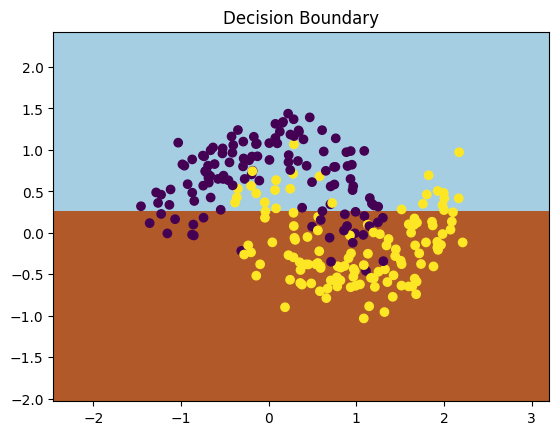

Test accuracy:  0.788


In [5]:
# TODO: Train a DecisionTreeClassifier with max_depth=1 and call results(clf)
clf_depth1 = DecisionTreeClassifier(max_depth=1, random_state=42)
results(clf_depth1)


Max depth: 3
Test data


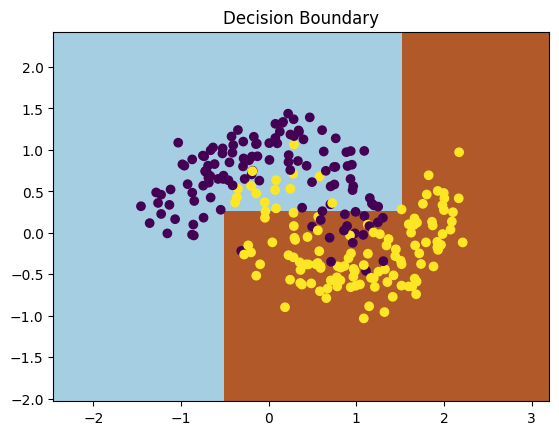

Test accuracy:  0.86

Max depth: 10
Test data


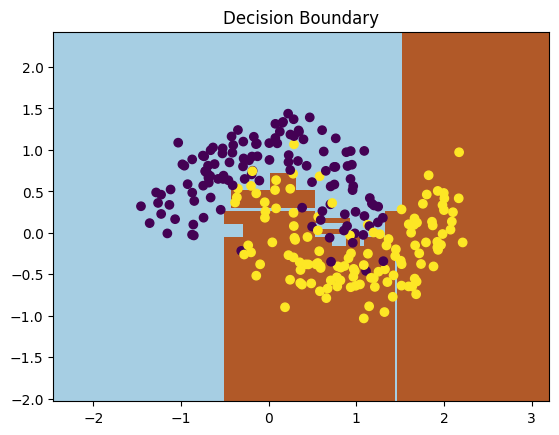

Test accuracy:  0.904


In [6]:
# TODO: Try at least two more depth values and observe how the boundary changes
for depth in [3, 10]:
    print(f'\nMax depth: {depth}')
    clf_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    results(clf_depth)

**Question 1.1:** What happens to the decision boundary as `max_depth` increases? 
Is there a risk of overfitting? Explain briefly.

*Your answer here:*

As `max_depth` increases, the decision boundary becomes more complex and non-linear, fitting tightly to the training points. This increases the risk of overfitting, as the model starts to memorize the noise and specifics of the training data resulting in worse generalization on unseen data.


## Task 1.2 – Bagging

Use `BaggingClassifier` with a `DecisionTreeClassifier(max_depth=30)` base estimator.
Try `n_estimators=1`, then increase it (e.g., 10, 50, 100) and compare test accuracy.
Also train a `RandomForestClassifier(max_depth=30)` and compare.


Test data


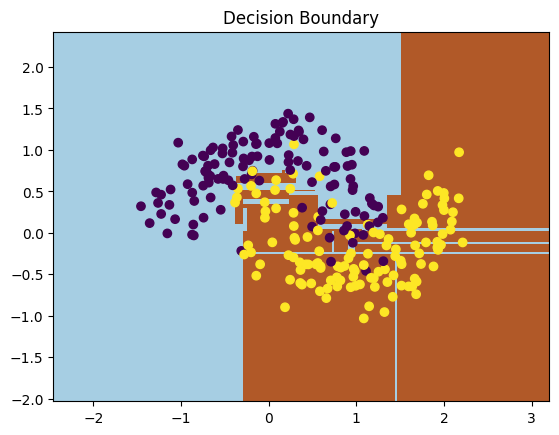

Test accuracy:  0.896


In [7]:
# TODO: BaggingClassifier with n_estimators=1
bagging_1 = BaggingClassifier(DecisionTreeClassifier(max_depth=30, random_state=42), n_estimators=1, random_state=42)
results(bagging_1)


BaggingClassifier with n_estimators: 10
Test data


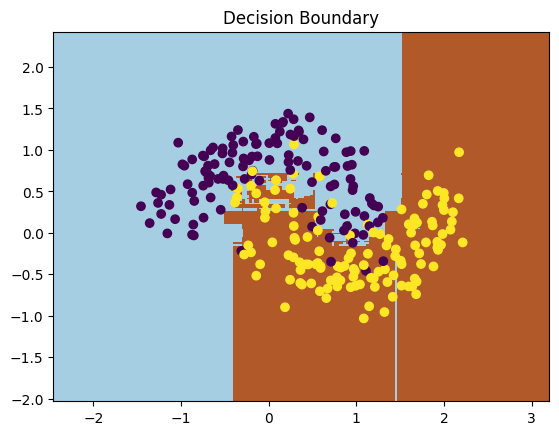

Test accuracy:  0.9

BaggingClassifier with n_estimators: 50
Test data


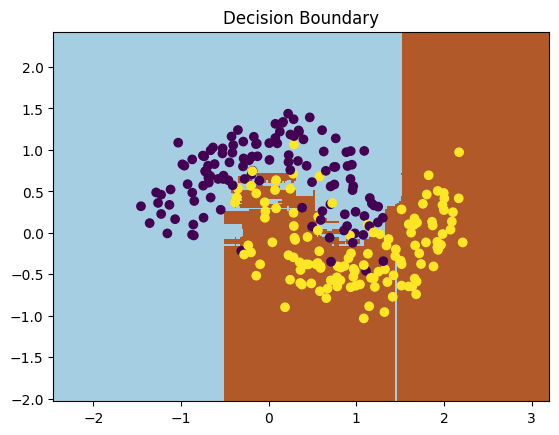

Test accuracy:  0.896

BaggingClassifier with n_estimators: 100
Test data


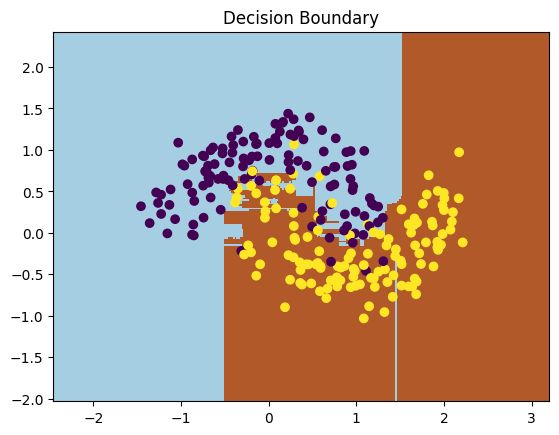

Test accuracy:  0.892


In [8]:
# TODO: BaggingClassifier with more estimators (try at least 2 values)
for n_est in [10, 50, 100]:
    print(f'\nBaggingClassifier with n_estimators: {n_est}')
    bagging_n = BaggingClassifier(DecisionTreeClassifier(max_depth=30, random_state=42), n_estimators=n_est, n_jobs=-1, random_state=42)
    results(bagging_n)

Test data


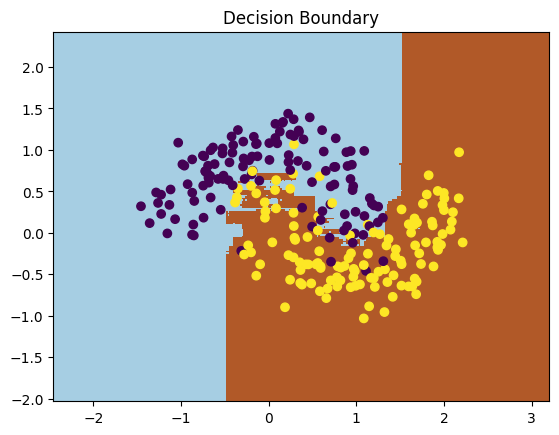

Test accuracy:  0.892


In [9]:
# TODO: RandomForestClassifier with max_depth=30
rf_clf = RandomForestClassifier(max_depth=30, n_estimators=100, n_jobs=-1, random_state=42)
results(rf_clf)

**Question 1.2:** Compare the decision boundaries of BaggingClassifier and RandomForestClassifier. 
What is the key difference between Bagging and Random Forest? 
How does increasing `n_estimators` affect performance and variance?

*Your answer here:*

Both models present complex boundaries because they aggregate multiple deep trees. However, Random Forest boundaries tend to be smoother and less overfitted to specific instances.

The key difference is that Bagging injects randomness only by bootstrapping records, whereas Random Forest also subsets features randomly at each split, further decorrelating the trees.

Increasing `n_estimators` directly reduces the variance of the model's predictions because of the averaging, leading to a much more stable and generalized boundary with better test performance, up to a point.


## Task 1.3 – Boosting (AdaBoost)

Train an `AdaBoostClassifier` using a `DecisionTreeClassifier(max_depth=1)` as the base estimator.
Use `algorithm='SAMME'`. Try at least **two different values** of `n_estimators` (e.g., 10, 100, 500).



AdaBoostClassifier with n_estimators: 10
Test data


c:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\dias\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


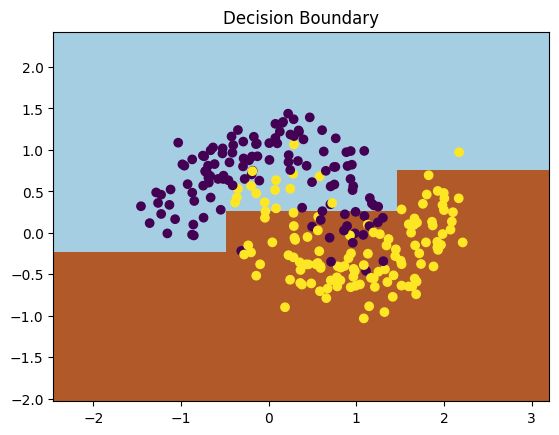

Test accuracy:  0.86

AdaBoostClassifier with n_estimators: 100


c:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\dias\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Test data


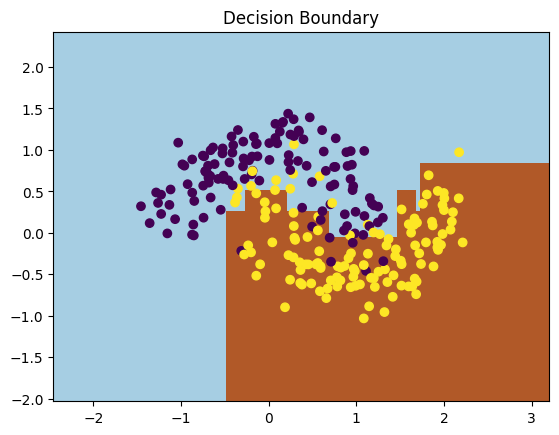

Test accuracy:  0.896

AdaBoostClassifier with n_estimators: 500


c:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\dias\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Test data


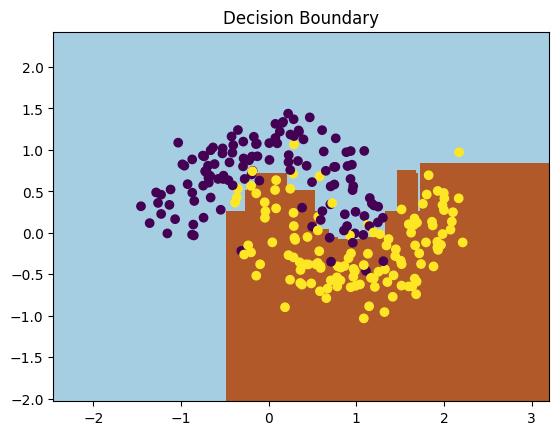

Test accuracy:  0.9


In [10]:
# TODO: AdaBoostClassifier — try multiple n_estimators values
for n_est in [10, 100, 500]:
    print(f'\nAdaBoostClassifier with n_estimators: {n_est}')
    ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=n_est, algorithm='SAMME', random_state=42)
    results(ada_clf)

**Question 1.3:** How does boosting differ from bagging conceptually? 
What is the role of the weak learner (`max_depth=1` tree) in AdaBoost?

*Your answer here:*

Bagging aims to reduce variance by independently training models in parallel and averaging them. Boosting aims to reduce bias by training models sequentially, where each new model attempts to correct the errors of the previous ones.

In AdaBoost, the weak learner provides a very simple initial rule slightly better than random guessing. Boosting focuses on the misclassified examples in subsequent iterations, sequentially building on this weak foundation to eventually form a highly accurate strong learner.


# Part 2: Precision and Recall on Imbalanced Data

In [11]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

In [12]:
# Data generation — do not modify
X, y = make_blobs(n_samples=1000, centers=2, n_features=2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Create imbalanced training set (keep only 1/5 of positive class)
pos = (y_train == 1).nonzero()[0]
neg = (y_train == 0).nonzero()[0]
idx = np.concatenate([pos[:int(len(pos) // 5)], neg])
X_train = X_train[idx]
y_train = y_train[idx]

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

## Task 2.1 – Visualize the Class Imbalance

Plot the training data, coloring each class differently. How imbalanced does the dataset look?


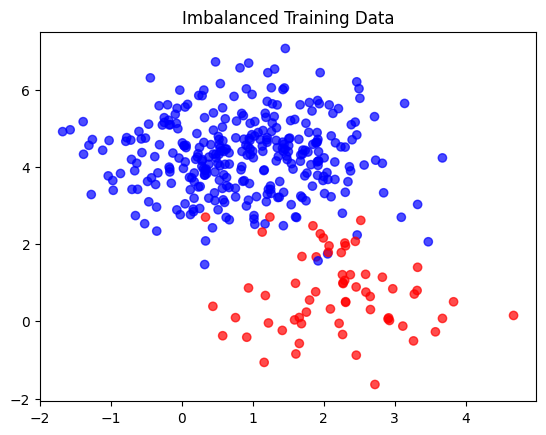

In [13]:
# TODO: Scatter plot of X_train, colored by class label (y_train)
plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', alpha=0.7)
plt.title('Imbalanced Training Data')
plt.show()

## Task 2.2 – Train and Evaluate (Accuracy, Precision, Recall)

Train a `DecisionTreeClassifier` on the imbalanced `X_train`/`y_train`.
Report accuracy, precision, and recall on both the **validation** and **test** sets.


In [14]:
from sklearn.tree import DecisionTreeClassifier

# TODO: Fit the classifier on X_train, y_train
dt_imba = DecisionTreeClassifier(random_state=42)
dt_imba.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
# TODO: Report accuracy, precision, and recall on the VALIDATION set
y_val_pred = dt_imba.predict(X_val)

print("Validation Set:")
print("Accuracy: ", dt_imba.score(X_val, y_val))
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:   ", recall_score(y_val, y_val_pred))

Validation Set:
Accuracy:  0.9270833333333334
Precision: 0.9090909090909091
Recall:    0.625


In [16]:
# TODO: Report accuracy, precision, and recall on the TEST set
y_test_pred = dt_imba.predict(X_test)

print("Test Set:")
print("Accuracy: ", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:   ", recall_score(y_test, y_test_pred))

Test Set:
Accuracy:  0.885
Precision: 0.9411764705882353
Recall:    0.8163265306122449


**Question 2.2:** Is there a gap between precision and recall? Why? 
Is accuracy a reliable metric here? What does it fail to capture?

*Your answer here:*

Yes, there is usually a gap. Given the heavy imbalance, the model naturally predicts the majority class to minimize errors. Thus, recall for the minority class drops significantly (it misses actual positives). Precision might stay somewhat decent if the few positives it predicts are accurate, but recall crashes.

Accuracy is highly unreliable here. A model could simply predict the majority class for all data and still get a very high accuracy. Accuracy completely fails to capture how poorly the model identifies the minority class.


# Part 3: Handling Imbalanced Data with Resampling

In [17]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

## Task 3.1 – Random Under-Sampling

Apply `RandomUnderSampler` to balance the training data.
Visualize the resampled data, then retrain your classifier and compare metrics.


In [18]:
# TODO: Apply RandomUnderSampler to (X_train, y_train)
# Store result as X_resampled, y_resampled
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

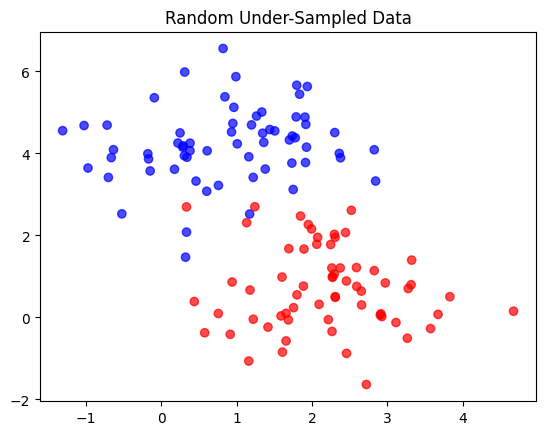

In [19]:
# TODO: Scatter plot of resampled data (X_resampled colored by y_resampled)
plt.figure()
plt.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='bwr', alpha=0.7)
plt.title('Random Under-Sampled Data')
plt.show()

In [20]:
# TODO: Retrain DecisionTreeClassifier on X_resampled, y_resampled
# Report accuracy, precision, and recall on validation AND test sets
dt_under = DecisionTreeClassifier(random_state=42)
dt_under.fit(X_resampled, y_resampled)

y_val_pred_us = dt_under.predict(X_val)
y_test_pred_us = dt_under.predict(X_test)

print("Validation Set:")
print("Accuracy: ", accuracy_score(y_val, y_val_pred_us))
print("Precision:", precision_score(y_val, y_val_pred_us))
print("Recall:   ", recall_score(y_val, y_val_pred_us))

print("\nTest Set:")
print("Accuracy: ", accuracy_score(y_test, y_test_pred_us))
print("Precision:", precision_score(y_test, y_test_pred_us))
print("Recall:   ", recall_score(y_test, y_test_pred_us))

Validation Set:
Accuracy:  0.9479166666666666
Precision: 0.8235294117647058
Recall:    0.875

Test Set:
Accuracy:  0.92
Precision: 0.9019607843137255
Recall:    0.9387755102040817


**Question 3.1:** Did precision and recall improve after under-sampling? 
What is the trade-off when removing majority-class samples?

*Your answer here:*

Recall usually improves remarkably because the class representation is balanced, making the model more willing to predict the positive class. However, precision can drop, as there are more false positives.

The trade-off is information loss. Under-sampling discards potentially useful majority-class data points, leaving fewer examples for the model to effectively learn the true underlying patterns.


## Task 3.2 – Over-Sampling with SMOTE

Apply `SMOTE` (Synthetic Minority Over-sampling Technique) to the original imbalanced `X_train`/`y_train`.
Retrain your classifier and compare with the under-sampling results.


In [21]:
# TODO: Apply SMOTE to (X_train, y_train)
# Retrain DecisionTreeClassifier
# Report accuracy, precision, and recall on validation AND test sets
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_smote, y_smote)

y_val_pred_sm = dt_smote.predict(X_val)
y_test_pred_sm = dt_smote.predict(X_test)

print("Validation Set (SMOTE):")
print("Accuracy: ", accuracy_score(y_val, y_val_pred_sm))
print("Precision:", precision_score(y_val, y_val_pred_sm))
print("Recall:   ", recall_score(y_val, y_val_pred_sm))

print("\nTest Set (SMOTE):")
print("Accuracy: ", accuracy_score(y_test, y_test_pred_sm))
print("Precision:", precision_score(y_test, y_test_pred_sm))
print("Recall:   ", recall_score(y_test, y_test_pred_sm))

Validation Set (SMOTE):
Accuracy:  0.9270833333333334
Precision: 0.9090909090909091
Recall:    0.625

Test Set (SMOTE):
Accuracy:  0.895
Precision: 0.9425287356321839
Recall:    0.8367346938775511


**Question 3.2:** Compare the three approaches (no resampling, under-sampling, SMOTE). 
Which gives the best balance between precision and recall? What are the pros and cons of each method?

*Your answer here:*

*   **No Resampling**: Gives high precision but terrible recall, keeping high overall accuracy merely because the data is imbalanced. Con: fails on minority class.
*   **Under-sampling**: Massively boosts recall but suffers some precision loss. Pro: speeds up training. Con: discards valuable majority-class data.
*   **SMOTE**: Consistently achieves the best balance between precision and recall. Pro: adds minority representation without losing majority data. Con: takes longer to process, and could generate synthetic examples in overlapping noisy regions.

Overall, SMOTE provides the most balanced and robust performance on minority representations.
